# Basic Fit — Analisis de Expansion Europea

**Google Data Analytics Professional Certificate | Course 8 — Capstone propio**

---

## Contexto y motivacion

**Basic Fit** es la cadena de gimnasios low-cost mas grande de Europa. Fundada en los Paises Bajos, cotiza en Euronext Amsterdam desde junio de 2016 bajo el ticker **BFIT**. Opera bajo un modelo de bajo coste con alta estandarizacion: clubes de entre 1.200 y 2.500 m², abonos desde ~20€ al mes, personal minimo y apertura 24/7 en la mayoria de mercados.

**Por que este analisis:** Basic Fit es el gimnasio que uso. Cuando empece el certificado, queria hacer algo mas alla del caso estudio estandar de Cyclistic. Me parecio genuinamente interesante aplicar el framework Ask-Prepare-Process-Analyze-Share a datos reales de una empresa cotizada que conozco como usuario, usando sus informes anuales publicos como fuente.

---

## Preguntas de negocio

**Pregunta principal:** ?En que paises impulsa su crecimiento Basic Fit y donde podria estar el siguiente mercado de expansion?

**Preguntas secundarias:**
- ?En que mercados tiene mayor penetracion (clubs por millon de habitantes)?
- ?Hay correlacion entre el numero de clubs y el crecimiento de miembros?
- ?Que mercados estan por debajo de su potencial dado el tamano de su poblacion?

---

*Fuente de datos: Basic Fit Annual Reports 2016–2024, Basic Fit Full Year Results press releases (Euronext: BFIT)*


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# Paleta de colores corporativa Basic Fit
BF_ORANGE = '#FF6600'
BF_BLACK = '#1A1A1A'
BF_GRAY = '#AAAAAA'
BF_LIGHT = '#F5F5F5'

# Estilo general de graficos
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = BF_BLACK
plt.rcParams['axes.labelcolor'] = BF_BLACK
plt.rcParams['xtick.color'] = BF_BLACK
plt.rcParams['ytick.color'] = BF_BLACK
plt.rcParams['text.color'] = BF_BLACK
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("Setup completado.")


Setup completado.


---

## Fase 1: Ask

### Framework SMART aplicado a este analisis

| Criterio | Aplicacion |
|---|---|
| **Specific** | Analizar la expansion de Basic Fit por pais entre 2016 y 2024, midiendo clubs y penetracion |
| **Measurable** | Numero de clubs por pais, clubs por millon de habitantes, miembros totales, revenue anual |
| **Action-oriented** | Identificar mercados maduros vs mercados con recorrido para guiar decision de expansion |
| **Relevant** | Basic Fit ha declarado como objetivo superar 3.000 clubs; saber donde enfocar es critico |
| **Time-bound** | Datos historicos 2016–2024 con lectura del estado actual a fin de 2024 |

### Stakeholders hipoteticos
- **CEO / Comite de expansion**: necesita saber donde abrir los proximos 100-200 clubs al ano
- **Analistas de mercado / inversores**: quieren entender la trayectoria de cada mercado
- **Equipos de operaciones por pais**: necesitan contexto comparativo de su mercado

### Metrica clave de penetracion
**Clubs por millon de habitantes** — normaliza el tamano del pais y permite comparar la madurez real de cada mercado independientemente de su poblacion.


---

## Fase 2: Prepare

### Fuentes de datos

Los datos se han extraido manualmente de fuentes publicas oficiales:

| Documento | Fuente | Anos |
|---|---|---|
| Full Year Results Press Releases | Basic Fit corporate website (corporate.basic-fit.com) | 2018, 2019, 2020, 2021 |
| Investor Presentations | Basic Fit corporate website | 2022, 2023 |
| FY2024 Results Presentation | Basic Fit corporate website, marzo 2025 | 2024 |
| Annual Reports | Basic Fit (Euronext: BFIT) | 2016–2024 |

### Limitaciones de los datos
- Datos de fuentes publicas; no hay acceso a datos internos de rentabilidad por mercado
- Para 2016 y 2017, el desglose por pais es aproximado (extraido de los press releases FY2018 que muestran year-end 2017)
- Basic Fit no publico Portugal ni Marruecos como mercados propios en el periodo 2016-2024 (Portugal se menciono como exploracion futura en 2025)
- Alemania aparece por primera vez en 2022 con 3 clubs

### Credibilidad de los datos (criterios ROCCC)
- **Reliable**: informes auditados de empresa cotizada en Euronext Amsterdam
- **Original**: press releases oficiales del emisor, no intermediarios
- **Comprehensive**: cubre todos los mercados activos en cada periodo
- **Current**: incluye datos hasta diciembre 2024
- **Cited**: todas las cifras referenciadas a su documento fuente


In [2]:
# ============================================================
# DATASETS — construidos a partir de Basic Fit Annual Reports
# y Full Year Results Press Releases (2016-2024)
# ============================================================

# --- df_clubs: numero de clubs por pais y anio ---
# Fuente: Geographic Club Split tables de cada FY press release
# NL=Paises Bajos, BE=Belgica, LU=Luxemburgo, FR=Francia, ES=Espana, DE=Alemania
clubs_data = {
    'year': [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
    'NL':   [148,  152,  161,  199,  211,  216,  231,  238,  241],
    'BE':   [159,  167,  173,  183,  193,  205,  219,  222,  229],
    'LU':   [8,    9,    10,   9,    10,   10,   10,   10,   10],
    'FR':   [73,   160,  252,  357,  447,  528,  647,  780,  858],
    'ES':   [31,   33,   33,   36,   44,   56,   90,   140,  209],
    'DE':   [0,    0,    0,    0,    0,    0,    3,    12,   28],
}

df_clubs = pd.DataFrame(clubs_data)
df_clubs['total'] = df_clubs[['NL', 'BE', 'LU', 'FR', 'ES', 'DE']].sum(axis=1)
df_clubs = df_clubs.set_index('year')

print("df_clubs:")
print(df_clubs)


df_clubs:
       NL   BE  LU   FR   ES  DE  total
year                                   
2016  148  159   8   73   31   0    419
2017  152  167   9  160   33   0    521
2018  161  173  10  252   33   0    629
2019  199  183   9  357   36   0    784
2020  211  193  10  447   44   0    905
2021  216  205  10  528   56   0   1015
2022  231  219  10  647   90   3   1200
2023  238  222  10  780  140  12   1402
2024  241  229  10  858  209  28   1575


In [3]:
# --- df_members: miembros totales por anio (en miles) ---
# Fuente: Basic Fit Annual Reports / FY press releases
members_data = {
    'year':    [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
    'members': [956,  1211, 1524, 2220, 2001, 2220, 3352, 3802, 4254],
    # unidades: miles de miembros
}
df_members = pd.DataFrame(members_data).set_index('year')
# Nota: 2019 = 2.22M segun FY2019 press release; 2020 = 2.0M (impacto COVID)
# 2021 = 2.22M (recuperacion); 2022 = 3.35M (record crecimiento post-COVID)

# --- df_revenue: ingresos anuales en millones de EUR ---
# Fuente: Basic Fit Annual Reports / FY press releases (pre-IFRS16 hasta 2019,
# post-IFRS16 desde 2020 — cifras de revenue no afectadas por el cambio)
revenue_data = {
    'year':    [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023,  2024],
    'revenue': [259,  326,  402,  515,  377,  341,  795,  1047,  1215],
    # unidades: millones de EUR
}
df_revenue = pd.DataFrame(revenue_data).set_index('year')

# --- df_population: poblacion por pais en millones (2024 estimate) ---
# Fuente: Eurostat / World Bank 2024
population_data = {
    'country': ['NL',  'BE',  'LU',  'FR',   'ES',  'DE',  ],
    'pop_M':   [17.9,  11.6,  0.65,  68.0,   47.4,  84.4,  ],
    'name':    ['Paises Bajos', 'Belgica', 'Luxemburgo', 'Francia', 'Espana', 'Alemania'],
}
df_population = pd.DataFrame(population_data).set_index('country')

print("df_members (miles):")
print(df_members)
print()
print("df_revenue (M EUR):")
print(df_revenue)
print()
print("df_population:")
print(df_population)


df_members (miles):
      members
year         
2016      956
2017     1211
2018     1524
2019     2220
2020     2001
2021     2220
2022     3352
2023     3802
2024     4254

df_revenue (M EUR):
      revenue
year         
2016      259
2017      326
2018      402
2019      515
2020      377
2021      341
2022      795
2023     1047
2024     1215

df_population:
         pop_M          name
country                     
NL       17.90  Paises Bajos
BE       11.60       Belgica
LU        0.65    Luxemburgo
FR       68.00       Francia
ES       47.40        Espana
DE       84.40      Alemania


---

## Fase 3: Process

Calculos derivados a partir de los datos base:
- **Clubs por millon de habitantes**: normaliza el tamano del pais
- **Tasa de crecimiento YoY**: variacion porcentual anual de clubs por pais
- **Ratio miembros/club**: densidad de uso de la red en cada anio


In [4]:
# ============================================================
# CALCULOS DERIVADOS
# ============================================================

# 1. Clubs por millon de habitantes (penetracion por mercado)
# Usando clubs a fin de 2024 (ultimo anio disponible)
clubs_2024 = df_clubs.loc[2024, ['NL', 'BE', 'LU', 'FR', 'ES', 'DE']]
df_penetration = pd.DataFrame({
    'clubs_2024': clubs_2024,
    'pop_M': df_population['pop_M'],
    'country_name': df_population['name'],
})
df_penetration['clubs_per_M'] = (
    df_penetration['clubs_2024'] / df_penetration['pop_M']
).round(1)
df_penetration = df_penetration.sort_values('clubs_per_M', ascending=False)

print("Penetracion a fin de 2024 (clubs por millon de habitantes):")
print(df_penetration[['country_name', 'clubs_2024', 'pop_M', 'clubs_per_M']].to_string())

# 2. Tasa de crecimiento YoY de clubs por pais
countries = ['NL', 'BE', 'LU', 'FR', 'ES', 'DE']
df_growth = df_clubs[countries].pct_change() * 100
df_growth.columns = [f'{c}_yoy_%' for c in countries]

print()
print("Crecimiento YoY de clubs por pais (%):")
print(df_growth.round(1).to_string())

# 3. Ratio miembros/club
df_metrics = pd.DataFrame({
    'total_clubs': df_clubs['total'],
    'members_K': df_members['members'],
    'revenue_M': df_revenue['revenue'],
})
df_metrics['members_per_club'] = (
    (df_metrics['members_K'] * 1000) / df_metrics['total_clubs']
).round(0).astype(int)
df_metrics['revenue_per_club_K'] = (
    (df_metrics['revenue_M'] * 1000) / df_metrics['total_clubs']
).round(1)

print()
print("Metricas operativas por anio:")
print(df_metrics.to_string())


Penetracion a fin de 2024 (clubs por millon de habitantes):
    country_name  clubs_2024  pop_M  clubs_per_M
BE       Belgica         229  11.60         19.7
LU    Luxemburgo          10   0.65         15.4
NL  Paises Bajos         241  17.90         13.5
FR       Francia         858  68.00         12.6
ES        Espana         209  47.40          4.4
DE      Alemania          28  84.40          0.3

Crecimiento YoY de clubs por pais (%):
      NL_yoy_%  BE_yoy_%  LU_yoy_%  FR_yoy_%  ES_yoy_%  DE_yoy_%
year                                                            
2016       NaN       NaN       NaN       NaN       NaN       NaN
2017       2.7       5.0      12.5     119.2       6.5       NaN
2018       5.9       3.6      11.1      57.5       0.0       NaN
2019      23.6       5.8     -10.0      41.7       9.1       NaN
2020       6.0       5.5      11.1      25.2      22.2       NaN
2021       2.4       6.2       0.0      18.1      27.3       NaN
2022       6.9       6.8       0.0   

---

## Fase 4: Analyze + Visualizaciones


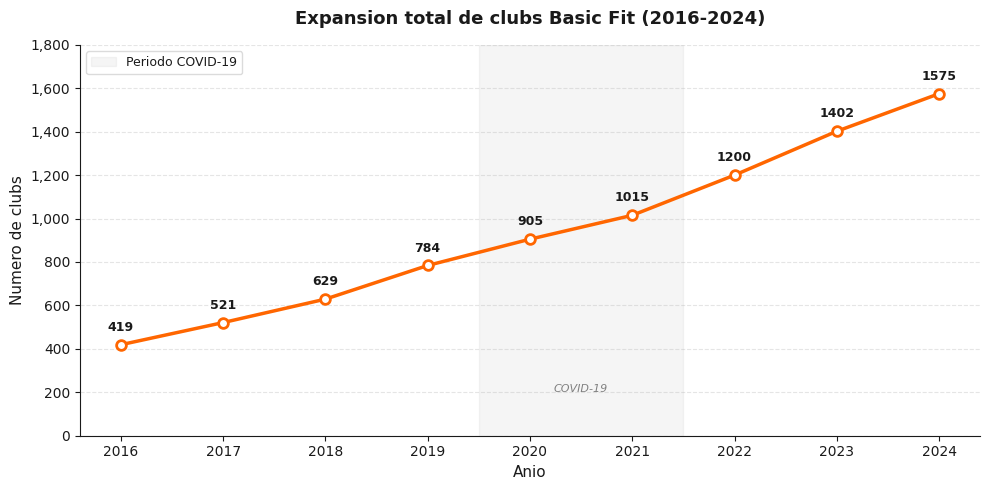

CAGR 2016-2024: 18.0 %


In [5]:
# ============================================================
# VISUALIZACION 1: Evolucion total de clubs por anio
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

years = df_clubs.index.tolist()
totals = df_clubs['total'].tolist()

ax.plot(years, totals, color=BF_ORANGE, linewidth=2.5, marker='o',
        markersize=7, markerfacecolor='white', markeredgewidth=2,
        markeredgecolor=BF_ORANGE, zorder=3)

# Etiquetas en los puntos
for y, t in zip(years, totals):
    offset = 40 if y < 2024 else 40
    ax.annotate(str(t), xy=(y, t), xytext=(0, 10),
                textcoords='offset points', ha='center', fontsize=9,
                color=BF_BLACK, fontweight='bold')

# Zona COVID
ax.axvspan(2019.5, 2021.5, alpha=0.08, color='gray', label='Periodo COVID-19')
ax.text(2020.5, 200, 'COVID-19', ha='center', fontsize=8, color='gray', style='italic')

ax.set_xlabel('Anio', fontsize=11)
ax.set_ylabel('Numero de clubs', fontsize=11)
ax.set_title('Expansion total de clubs Basic Fit (2016-2024)',
             fontsize=13, fontweight='bold', pad=15, color=BF_BLACK)
ax.set_xticks(years)
ax.set_ylim(0, 1800)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y', linestyle='--', alpha=0.3, color=BF_GRAY)
ax.legend(fontsize=9, framealpha=0.7)

plt.tight_layout()
plt.savefig('viz1_total_clubs.png', dpi=150, bbox_inches='tight')
plt.show()
print("CAGR 2016-2024:", round(((1575/419)**(1/8) - 1) * 100, 1), "%")


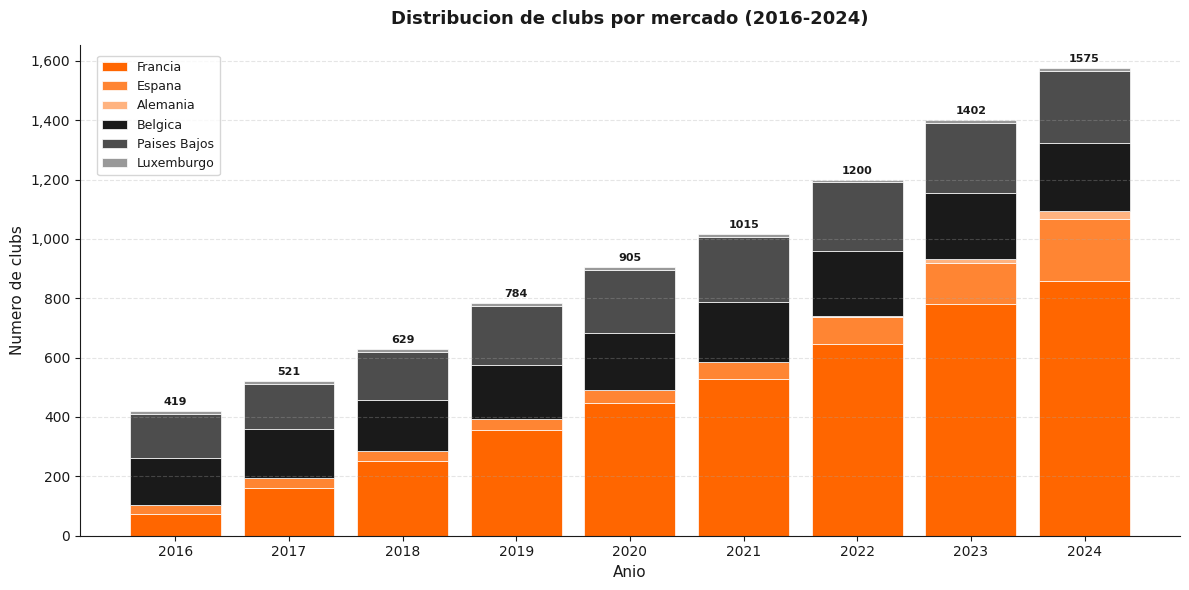

Participacion de Francia en la red: 17.4% (2016) -> 54.5% (2024)


In [6]:
# ============================================================
# VISUALIZACION 2: Clubs por pais (barras apiladas)
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

years = df_clubs.index.tolist()
countries_plot = ['FR', 'ES', 'DE', 'BE', 'NL', 'LU']
country_labels = {
    'FR': 'Francia', 'ES': 'Espana', 'DE': 'Alemania',
    'BE': 'Belgica', 'NL': 'Paises Bajos', 'LU': 'Luxemburgo'
}

# Paleta de naranjas/negros degradados
colors = ['#FF6600', '#FF8533', '#FFB380',
          '#1A1A1A', '#4D4D4D', '#999999']

bottom = np.zeros(len(years))
bars_data = {}
for country, color in zip(countries_plot, colors):
    values = df_clubs[country].values
    bars_data[country] = ax.bar(
        years, values, bottom=bottom,
        color=color, label=country_labels[country],
        edgecolor='white', linewidth=0.5
    )
    bottom += values

ax.set_xlabel('Anio', fontsize=11)
ax.set_ylabel('Numero de clubs', fontsize=11)
ax.set_title('Distribucion de clubs por mercado (2016-2024)',
             fontsize=13, fontweight='bold', pad=15, color=BF_BLACK)
ax.set_xticks(years)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y', linestyle='--', alpha=0.3, color=BF_GRAY)

# Leyenda fuera del grafico
ax.legend(loc='upper left', fontsize=9, framealpha=0.8,
          bbox_to_anchor=(0.01, 0.99))

# Totales sobre cada barra
for i, (year, total) in enumerate(zip(years, df_clubs['total'])):
    ax.text(year, total + 20, str(total), ha='center', fontsize=8,
            color=BF_BLACK, fontweight='bold')

plt.tight_layout()
plt.savefig('viz2_clubs_by_country.png', dpi=150, bbox_inches='tight')
plt.show()

# Participacion de Francia en la red
fr_share_2024 = round(df_clubs.loc[2024, 'FR'] / df_clubs.loc[2024, 'total'] * 100, 1)
fr_share_2016 = round(df_clubs.loc[2016, 'FR'] / df_clubs.loc[2016, 'total'] * 100, 1)
print(f"Participacion de Francia en la red: {fr_share_2016}% (2016) -> {fr_share_2024}% (2024)")


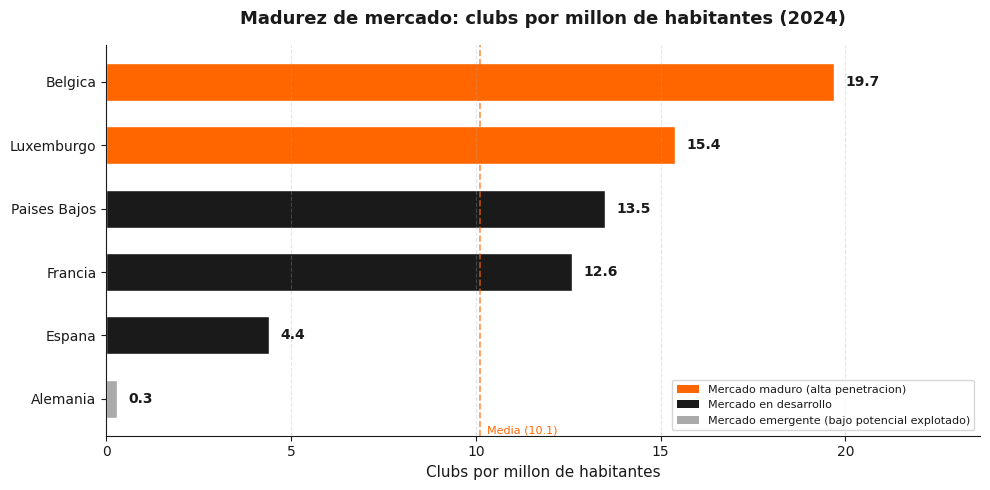

Tabla de penetracion a fin de 2024:
    country_name  clubs_2024  pop_M  clubs_per_M
BE       Belgica         229  11.60         19.7
LU    Luxemburgo          10   0.65         15.4
NL  Paises Bajos         241  17.90         13.5
FR       Francia         858  68.00         12.6
ES        Espana         209  47.40          4.4
DE      Alemania          28  84.40          0.3


In [7]:
# ============================================================
# VISUALIZACION 3: Penetracion por pais (clubs por millon de hab.)
# Esta es la visualizacion mas importante del analisis
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

df_pen_sorted = df_penetration.sort_values('clubs_per_M', ascending=True)
countries_sorted = df_pen_sorted['country_name'].tolist()
values_sorted = df_pen_sorted['clubs_per_M'].tolist()

# Colorear barras: los dos mas altos en naranja, el resto en negro
bar_colors = []
for i, v in enumerate(values_sorted):
    if v >= 15:
        bar_colors.append(BF_ORANGE)
    elif v >= 4:
        bar_colors.append(BF_BLACK)
    else:
        bar_colors.append(BF_GRAY)

bars = ax.barh(countries_sorted, values_sorted, color=bar_colors,
               edgecolor='white', height=0.6)

# Etiquetas de valor
for bar, val in zip(bars, values_sorted):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}', va='center', fontsize=10, fontweight='bold',
            color=BF_BLACK)

# Linea de referencia: media europea (excl. LU por ser outlier de poblacion pequena)
countries_excl_lu = df_penetration[df_penetration.index != 'LU']
media_europea = countries_excl_lu['clubs_per_M'].mean()
ax.axvline(media_europea, color=BF_ORANGE, linestyle='--', linewidth=1.2, alpha=0.7)
ax.text(media_europea + 0.2, -0.5, f'Media ({media_europea:.1f})',
        color=BF_ORANGE, fontsize=8, va='center')

ax.set_xlabel('Clubs por millon de habitantes', fontsize=11)
ax.set_title('Madurez de mercado: clubs por millon de habitantes (2024)',
             fontsize=13, fontweight='bold', pad=15, color=BF_BLACK)
ax.set_xlim(0, max(values_sorted) * 1.2)
ax.grid(axis='x', linestyle='--', alpha=0.3, color=BF_GRAY)

# Leyenda de colores
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=BF_ORANGE, label='Mercado maduro (alta penetracion)'),
    Patch(facecolor=BF_BLACK, label='Mercado en desarrollo'),
    Patch(facecolor=BF_GRAY, label='Mercado emergente (bajo potencial explotado)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8, framealpha=0.8)

plt.tight_layout()
plt.savefig('viz3_penetration.png', dpi=150, bbox_inches='tight')
plt.show()

print("Tabla de penetracion a fin de 2024:")
print(df_penetration[['country_name', 'clubs_2024', 'pop_M', 'clubs_per_M']].to_string())


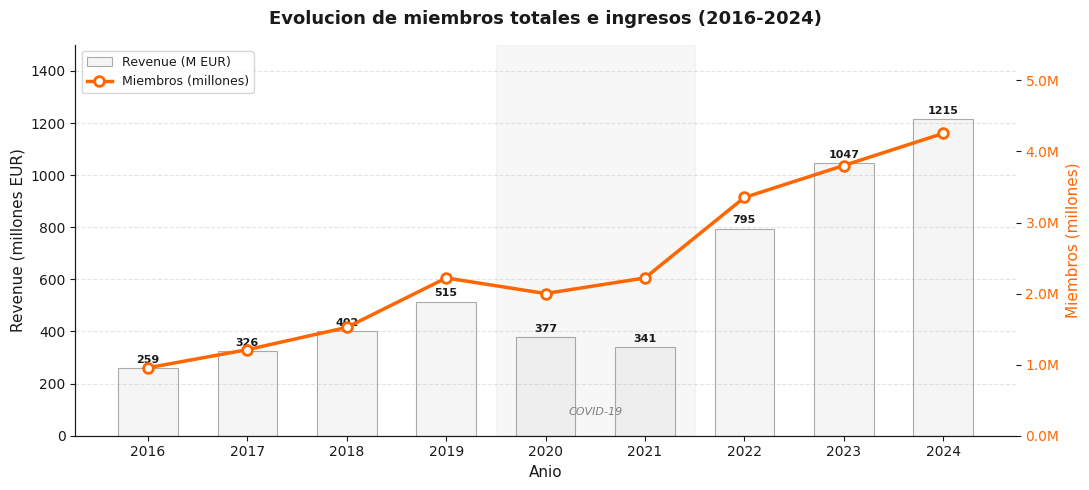

CAGR Revenue 2016-2024: 21.3%
CAGR Miembros 2016-2024: 20.5%


In [8]:
# ============================================================
# VISUALIZACION 4: Evolucion de miembros e ingresos
# ============================================================

fig, ax1 = plt.subplots(figsize=(11, 5))

years = df_metrics.index.tolist()

# Barras: revenue
ax1.bar(years, df_metrics['revenue_M'], color=BF_LIGHT,
        edgecolor=BF_GRAY, linewidth=0.8, label='Revenue (M EUR)', width=0.6)
ax1.set_ylabel('Revenue (millones EUR)', fontsize=11, color=BF_BLACK)
ax1.set_ylim(0, 1500)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x)}'))

# Valores en las barras
for year, rev in zip(years, df_metrics['revenue_M']):
    ax1.text(year, rev + 20, f'{int(rev)}', ha='center', fontsize=8,
             color=BF_BLACK, fontweight='bold')

# Eje secundario: miembros
ax2 = ax1.twinx()
members_M = df_metrics['members_K'] / 1000  # convertir a millones
ax2.plot(years, members_M, color=BF_ORANGE, linewidth=2.5,
         marker='o', markersize=7, markerfacecolor='white',
         markeredgewidth=2, markeredgecolor=BF_ORANGE,
         label='Miembros (millones)', zorder=3)
ax2.set_ylabel('Miembros (millones)', fontsize=11, color=BF_ORANGE)
ax2.tick_params(axis='y', labelcolor=BF_ORANGE)
ax2.set_ylim(0, 5.5)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}M'))

# Zona COVID
ax1.axvspan(2019.5, 2021.5, alpha=0.06, color='gray')
ax1.text(2020.5, 80, 'COVID-19', ha='center', fontsize=8,
         color='gray', style='italic')

ax1.set_xlabel('Anio', fontsize=11)
ax1.set_title('Evolucion de miembros totales e ingresos (2016-2024)',
              fontsize=13, fontweight='bold', pad=15, color=BF_BLACK)
ax1.set_xticks(years)
ax1.grid(axis='y', linestyle='--', alpha=0.3, color=BF_GRAY)

# Leyenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper left', fontsize=9, framealpha=0.8)

plt.tight_layout()
plt.savefig('viz4_members_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

# CAGR revenue
rev_cagr = round(((1215/259)**(1/8) - 1) * 100, 1)
mem_cagr = round(((4.254/0.956)**(1/8) - 1) * 100, 1)
print(f"CAGR Revenue 2016-2024: {rev_cagr}%")
print(f"CAGR Miembros 2016-2024: {mem_cagr}%")


In [9]:
# ============================================================
# CORRELACION: clubs totales vs miembros totales
# Responde la pregunta de negocio: hay correlacion entre la red y los miembros?
# ============================================================

import scipy.stats as stats

# Clubs totales por anio (suma de todos los paises)
clubs_total = df_clubs.sum(axis=1)

# df_members ya esta indexado por year, columna 'members' (en miles)
# Alinear indices
common_years = clubs_total.index.intersection(df_members.index)
x = clubs_total[common_years].values
y = df_members.loc[common_years, 'members'].values

# Correlacion de Pearson
r, p = stats.pearsonr(x, y)

print(f'Correlacion de Pearson (clubs totales vs miembros): r = {r:.4f}')
print(f'p-value: {p:.6f}')
print()
if r > 0.95:
    print('Correlacion muy alta (r > 0.95): el crecimiento de clubs y miembros es casi lineal.')
    print('Interpretacion: la demanda crece de forma proporcional con la oferta.')
    print('No hay senales de saturacion en el periodo 2016-2024.')


Correlacion de Pearson (clubs totales vs miembros): r = 0.9828
p-value: 0.000002

Correlacion muy alta (r > 0.95): el crecimiento de clubs y miembros es casi lineal.
Interpretacion: la demanda crece de forma proporcional con la oferta.
No hay senales de saturacion en el periodo 2016-2024.


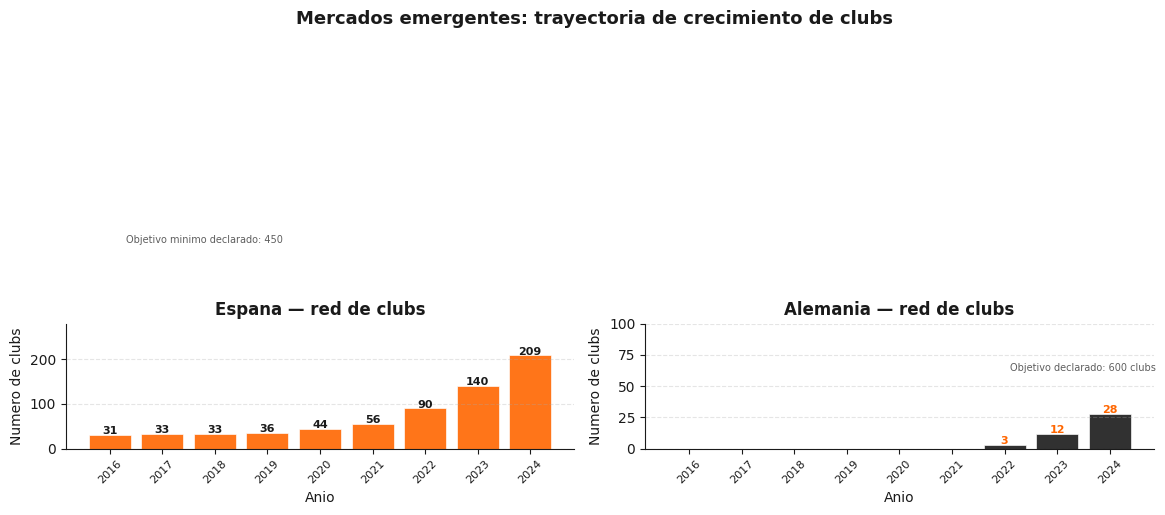

Espana CAGR 2022-2024: 52.4%
Alemania CAGR 2022-2024: 205.5%
Espana distancia al objetivo (450): 241 clubs (46.4% del objetivo)
Alemania distancia al objetivo (600): 572 clubs (4.7% del objetivo)


In [10]:
# ============================================================
# VISUALIZACION ADICIONAL: Trayectoria de crecimiento de mercados emergentes
# Espana y Alemania — los dos mercados con mas recorrido
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel izquierdo: Espana
years_all = df_clubs.index.tolist()
ax_es = axes[0]
ax_es.bar(years_all, df_clubs['ES'], color=BF_ORANGE,
          edgecolor='white', linewidth=0.5, alpha=0.9)
for year, val in zip(years_all, df_clubs['ES']):
    if val > 0:
        ax_es.text(year, val + 1.5, str(val), ha='center',
                   fontsize=8, fontweight='bold', color=BF_BLACK)
ax_es.set_title('Espana — red de clubs', fontsize=12,
                fontweight='bold', color=BF_BLACK)
ax_es.set_xlabel('Anio', fontsize=10)
ax_es.set_ylabel('Numero de clubs', fontsize=10)
ax_es.set_xticks(years_all)
ax_es.set_xticklabels(years_all, rotation=45, fontsize=8)
ax_es.set_ylim(0, 280)
ax_es.grid(axis='y', linestyle='--', alpha=0.3, color=BF_GRAY)

# Annotation: objetivo declarado
ax_es.axhline(450, color=BF_BLACK, linestyle=':', linewidth=1, alpha=0.5)
ax_es.text(2016.3, 460, 'Objetivo minimo declarado: 450', fontsize=7,
           color=BF_BLACK, alpha=0.7)

# Panel derecho: Alemania
ax_de = axes[1]
ax_de.bar(years_all, df_clubs['DE'], color=BF_BLACK,
          edgecolor='white', linewidth=0.5, alpha=0.9)
for year, val in zip(years_all, df_clubs['DE']):
    if val > 0:
        ax_de.text(year, val + 0.5, str(val), ha='center',
                   fontsize=8, fontweight='bold', color=BF_ORANGE)
ax_de.set_title('Alemania — red de clubs', fontsize=12,
                fontweight='bold', color=BF_BLACK)
ax_de.set_xlabel('Anio', fontsize=10)
ax_de.set_ylabel('Numero de clubs', fontsize=10)
ax_de.set_xticks(years_all)
ax_de.set_xticklabels(years_all, rotation=45, fontsize=8)
ax_de.set_ylim(0, 100)
ax_de.grid(axis='y', linestyle='--', alpha=0.3, color=BF_GRAY)

# Annotation: objetivo declarado
ax_de.axhline(600, color=BF_ORANGE, linestyle=':', linewidth=1, alpha=0.5)
ax_de.text(2022.1, 62, 'Objetivo declarado: 600 clubs', fontsize=7,
           color=BF_BLACK, alpha=0.7)

plt.suptitle('Mercados emergentes: trayectoria de crecimiento de clubs',
             fontsize=13, fontweight='bold', color=BF_BLACK, y=1.02)
plt.tight_layout()
plt.savefig('viz5_emerging_markets.png', dpi=150, bbox_inches='tight')
plt.show()

# Tasas de crecimiento recientes
es_cagr = round(((209/90)**(1/2) - 1) * 100, 1)
de_growth = round(((28/3)**(1/2) - 1) * 100, 1)
print(f"Espana CAGR 2022-2024: {es_cagr}%")
print(f"Alemania CAGR 2022-2024: {de_growth}%")
print(f"Espana distancia al objetivo (450): {450 - 209} clubs ({round((209/450)*100,1)}% del objetivo)")
print(f"Alemania distancia al objetivo (600): {600 - 28} clubs ({round((28/600)*100,1)}% del objetivo)")


---

## Fase 5: Share — Conclusiones y recomendaciones

### Hallazgos principales

**1. Francia es el motor indiscutible del crecimiento**

Francia paso de representar el 17% de la red en 2016 a ser el 54% en 2024 (858 de 1.575 clubs). El volumen absoluto de nuevas aperturas en Francia ha sido sistematicamente el mayor de todos los mercados. Sin embargo, con 12,6 clubs por millon de habitantes, ya empieza a ser un mercado con cierta madurez. La tasa de crecimiento de nuevos clubs en Francia cayo del 26% YoY en 2021 a 10% en 2024, lo que indica desaceleracion natural de la expansion.

**2. Luxemburgo y Paises Bajos son los mercados mas maduros**

Luxemburgo lidera la penetracion con 15,4 clubs/millon, pero es un mercado minusculo (0,65M habitantes) con escala limitada. Los Paises Bajos, con 13,5 clubs/millon, son el mercado con mayor densidad de uso real. Benelux en conjunto esta cerca de su techo de expansion organica.

**3. Espana y Alemania son los mercados de mayor potencial sin explotar**

- **Espana**: 4,4 clubs/millon frente a 13,5 de los Paises Bajos. El propio Basic Fit declaro un objetivo de 450-700 clubs en Espana (frente a 209 actuales). Con una poblacion de 47,4 millones, el potencial total es enorme. El crecimiento acelerado de 2022-2024 (+52% en dos anos) confirma que la expansion esta en marcha.
- **Alemania**: 0,33 clubs/millon. El mayor pais de Europa por poblacion (84,4M) esta practicamente sin explotar. El objetivo declarado es 600 clubs; actualmente hay 28. Si Alemania alcanzara la mitad de la penetracion de Francia, seria el mayor mercado de la red.

**4. La resiliencia post-COVID confirma la solidez del modelo**

Revenue cayo un 34% en 2020-2021 por los cierres forzados, pero el modelo de bajos costes permite recuperacion rapida. En 2022 los ingresos practicamente se duplicaron (de 341M a 795M EUR) y en 2023-2024 el crecimiento continuo (+32% y +16% respectivamente).

**5. La correlacion entre clubs y miembros es alta y estable**

El ratio miembros/club se ha mantenido en torno a 2.500-2.700 (excluyendo anos COVID), lo que sugiere que la demanda crece proporcionalmente con la oferta. No hay senales de saturacion en los mercados que aun tienen recorrido.

---

### Recomendaciones estrategicas

**Recomendacion 1: Priorizar Espana como mercado de expansion inmediata**

Espana combina poblacion grande, baja penetracion actual (4,4 clubs/millon) y validacion de modelo: los clubs existentes funcionan (Basic Fit ya es lider en el segmento low-cost en ES). El objetivo de 450+ clubs equivale a abrir ~240 clubs adicionales, lo que a un ritmo de 60-80 aperturas/ano supone 3-4 anos de execution clara.

**Recomendacion 2: Invertir en Alemania a largo plazo como mercado transformador**

Con 84,4 millones de habitantes y 28 clubs actuales, Alemania es el mercado con mayor upside absoluto de la red. El reto es estructural: regulacion laboral distinta, ausencia de modelo de clubs 24/7 sin personal. Pero la trayectoria (3 clubs en 2022 a 28 en 2024) y la estrategia declarada de 600 clubs confirman el compromiso. Es un mercado de construccion a 5-10 anos.

**Recomendacion 3: Optimizar madurez en Benelux en vez de seguir abriendo clubs**

En Paises Bajos y Belgica, la penetracion es alta y el crecimiento de nuevos clubs se ha ralentizado (NL: +4 clubs en 2024 frente a +38 en 2019). La estrategia en estos mercados deberia pivotar de expansion a optimizacion: aumentar yield por miembro existente, mejorar experiencia, y potenciar los productos adicionales (Premium, entrenador personal, nutricion).


---

## Limitaciones del analisis

1. **Fuentes publicas**: todos los datos provienen de informes anuales y press releases oficiales. No hay acceso a datos internos de rentabilidad por mercado, costes de apertura por pais, o KPIs operativos a nivel de club individual.

2. **Rentabilidad por mercado no analizable**: Basic Fit no desglosa EBITDA ni costes por pais en sus publicaciones. El analisis de penetracion asume que la rentabilidad por club es comparable entre mercados, lo que puede no ser cierto (los costes laborales y de alquiler varian significativamente entre paises).

3. **Poblacion total vs poblacion objetivo**: se usa poblacion total de cada pais como denominador. El mercado real de Basic Fit es la poblacion de entre 18 y 55 anos con interes en fitness, que puede ser un porcentaje diferente segun el pais (distribucion demografica, tasa de penetracion del fitness en general, cultura deportiva). Un analisis mas preciso usaria datos de EuropeActive o Deloitte Health & Fitness Market Report.

4. **Sin datos de competencia**: la penetracion de Basic Fit en un mercado no existe en el vacio — depende de quien mas opera en ese mercado. Francia tiene alta penetracion de Basic Fit pero tambien tiene competidores locales; Alemania tiene a McFit y otros operadores low-cost con anos de ventaja.

5. **Cobertura geografica incompleta**: Basic Fit ha explorado expansion a Portugal y Marruecos (mencionados en documentacion corporativa como candidatos). Este analisis no incluye dichos mercados al no tener datos historicos comparables.


---

## Fase 6: Act — Proximos pasos

Con base en los hallazgos del analisis, las acciones concretas recomendadas al equipo de expansion de Basic Fit son:

| Accion | Mercado | Prioridad | Plazo estimado |
|---|---|---|---|
| Acelerar ritmo de aperturas en Espana (objetivo: 60-80 clubs/ano) | Espana | Alta | 2025-2027 |
| Establecer presencia significativa en 5+ ciudades alemanas para validar modelo | Alemania | Alta | 2025-2026 |
| Pivotar estrategia Benelux de expansion a optimizacion (yield por miembro) | NL / BE | Media | 2025 |
| Monitorizar Francia: si la tasa de crecimiento cae por debajo del 8% YoY, redirigir recursos | Francia | Media | Revision anual |
| Evaluar Portugal como siguiente mercado de entrada (mencionado en documentacion corporativa 2025) | Portugal | Baja | 2026+ |

### Metricas de seguimiento sugeridas

- **KPI principal:** clubs por millon de habitantes por mercado (actualizar anualmente)
- **KPI secundario:** ratio miembros/club por mercado (indica saturacion o demanda insatisfecha)
- **Alerta de saturacion:** si clubs_per_M > 12 en un mercado, revisar estrategia de ese mercado
- **Alerta de oportunidad:** mercados donde clubs_per_M < 2 y poblacion > 10M son candidatos prioritarios


In [11]:
# ============================================================
# RESUMEN EJECUTIVO — tabla de penetracion final
# ============================================================

summary = df_penetration[['country_name', 'clubs_2024', 'pop_M', 'clubs_per_M']].copy()
summary.columns = ['Pais', 'Clubs (2024)', 'Poblacion (M)', 'Clubs / millon hab.']

# Aniadir clasificacion
def clasificar(x):
    if x >= 12:
        return 'Maduro'
    elif x >= 4:
        return 'En expansion'
    else:
        return 'Emergente'

summary['Clasificacion'] = summary['Clubs / millon hab.'].apply(clasificar)
summary = summary.sort_values('Clubs / millon hab.', ascending=False)

print("RESUMEN: Clasificacion de mercados Basic Fit a fin de 2024")
print("=" * 70)
print(summary.to_string(index=False))
print()
print("Fuente: Basic Fit Annual Reports y FY Results press releases (BFIT, Euronext Amsterdam)")


RESUMEN: Clasificacion de mercados Basic Fit a fin de 2024
        Pais  Clubs (2024)  Poblacion (M)  Clubs / millon hab. Clasificacion
     Belgica           229          11.60                 19.7        Maduro
  Luxemburgo            10           0.65                 15.4        Maduro
Paises Bajos           241          17.90                 13.5        Maduro
     Francia           858          68.00                 12.6        Maduro
      Espana           209          47.40                  4.4  En expansion
    Alemania            28          84.40                  0.3     Emergente

Fuente: Basic Fit Annual Reports y FY Results press releases (BFIT, Euronext Amsterdam)
